## Pneumonia Detection porject

## We are building a model that detect where a patient have pnemonia or not on the basis of chest xray

### Step1 : Library

In [21]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

import tensorflow as tf

from tensorflow import keras # CNN
from keras import layers 
from tensorflow.keras.models import Sequential # model

from tensorflow.keras.layers import Conv2D, MaxPooling2D # 2d
from tensorflow.keras.utils import image_dataset_from_directory 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

import os
import matplotlib.image as mpimg


### Step2: Load Dataset

In [12]:
path = "data/chest_xray/train"
classes = os.listdir(path)

print(classes)

['.DS_Store', 'PNEUMONIA', 'NORMAL']


In [13]:
Pneumonia_dir = os.path.join(path+ '/' + classes[1])
Normal_dir = os.path.join(path+ '/' + classes[2])

print(Pneumonia_dir, Normal_dir)

data/chest_xray/train/PNEUMONIA data/chest_xray/train/NORMAL


In [14]:
pneumonia_names = os.listdir(Pneumonia_dir)
normal_name = os.listdir(Normal_dir)

print(f"there are: {len(pneumonia_names)}, images of pneumonia infected patients")
print(f"there are: {len(normal_name)}, images of normal images in tranning dataset patients")

there are: 3876, images of pneumonia infected patients
there are: 1342, images of normal images in tranning dataset patients


## Displaying the 16 images in each types

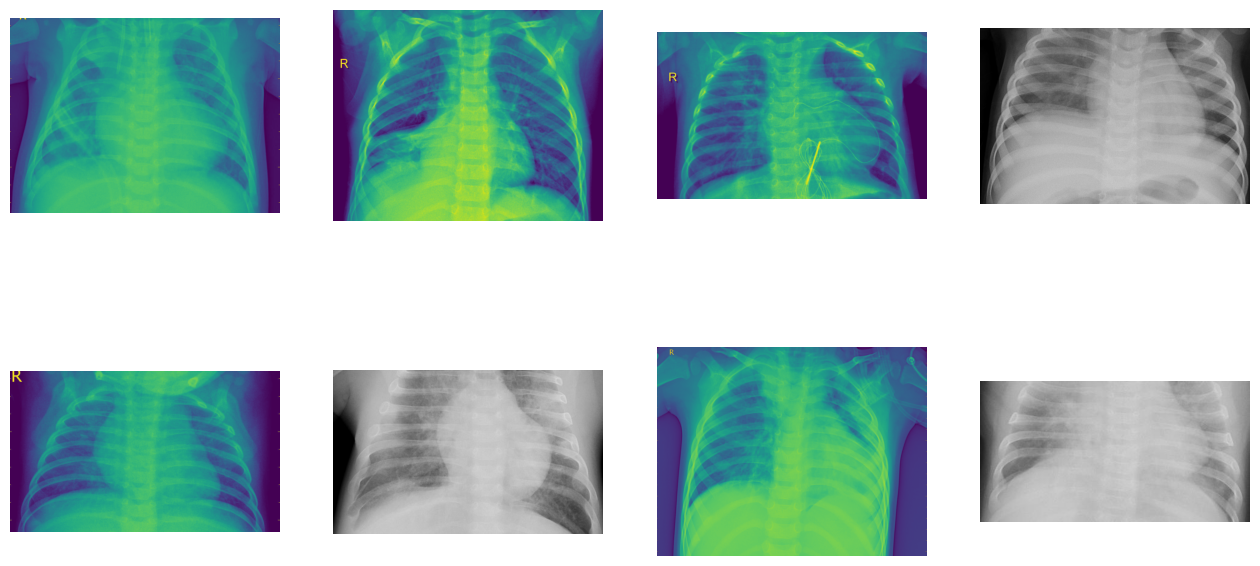

In [15]:
# Set the figure size
fig = plt.gcf()
fig.set_size_inches(16, 8)

# Select the starting index for the images to display
pic_index = 210

# Create lists of the file paths for the 16 images to display
pneumonia_images = [os.path.join(Pneumonia_dir, fname)

for fname in pneumonia_names[pic_index-8:pic_index]]

# Loop through the image paths and display each image in a subplot
for i, img_path in enumerate(pneumonia_images):
    sp = plt.subplot(2, 4, i+1)
    sp.axis('Off')

    # Read in the image using Matplotlib's imread() function
    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

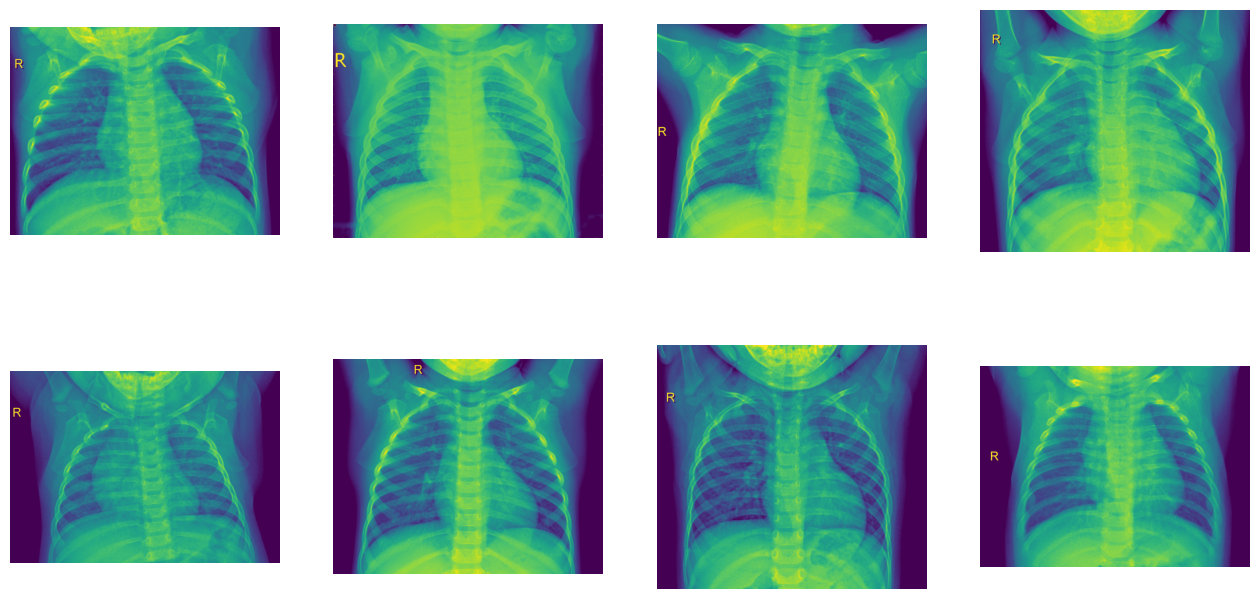

In [16]:
# Set the figure size
fig = plt.gcf()
fig.set_size_inches(16, 8)

# Select the starting index for the images to display
pic_index = 210

# Create lists of the file paths for the 16 images to display
pneumonia_images = [os.path.join(Normal_dir, fname)

for fname in normal_name[pic_index-8:pic_index]]

# Loop through the image paths and display each image in a subplot
for i, img_path in enumerate(pneumonia_images):
    sp = plt.subplot(2, 4, i+1)
    sp.axis('Off')

    # Read in the image using Matplotlib's imread() function
    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

## Data Preprocessing and Training

In [19]:
Train = keras.utils.image_dataset_from_directory(
    directory = 'data/chest_xray/train',
    labels = "inferred",
    label_mode = "categorical",
    batch_size = 32,
    image_size = (256, 256)
)

Found 5216 files belonging to 2 classes.


In [27]:
Test = keras.utils.image_dataset_from_directory(
    directory = 'data/chest_xray/test',
    labels = "inferred",
    label_mode = "categorical",
    batch_size = 32,
    image_size = (256, 256)
)

Found 624 files belonging to 2 classes.


In [32]:
Validation = keras.utils.image_dataset_from_directory(
    directory='data/chest_xray/val',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256, 256)
)

Found 16 files belonging to 2 classes.


## Model Archetecture

In [28]:
model = tf.keras.models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(2, activation='sigmoid')
])

/Users/pembagelusherpa/.pyenv/versions/3.11.5/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,313,474 (27.90 MB)

 Trainable params: 7,309,378 (27.88 MB)

 Non-trainable params: 4,096 (16.00 KB)

## model archetecture

In [30]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)


In [33]:
# training the model 

history = model.fit(Train, epochs=10, validation_data=Validation)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9176 - loss: 0.2474 - val_accuracy: 0.6250 - val_loss: 0.9369
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9507 - loss: 0.1544 - val_accuracy: 0.8750 - val_loss: 0.2052
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.9624 - loss: 0.1094 - val_accuracy: 0.5000 - val_loss: 3.5614
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9618 - loss: 0.1104 - val_accuracy: 0.5000 - val_loss: 1.5068
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.9707 - loss: 0.0834 - val_accuracy: 0.5000 - val_loss: 2.0786
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 987ms/step - accuracy: 0.9686 - loss: 0.0911 - val_accuracy: 0.8750 - val_loss: 0.3398
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9705 - loss: 0.0838 - val_accuracy: 0.5000 - val_loss: 2.9708
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9730 - loss: 0.0696 - val_a

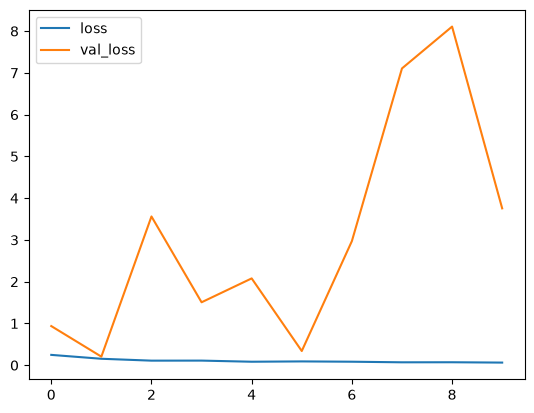

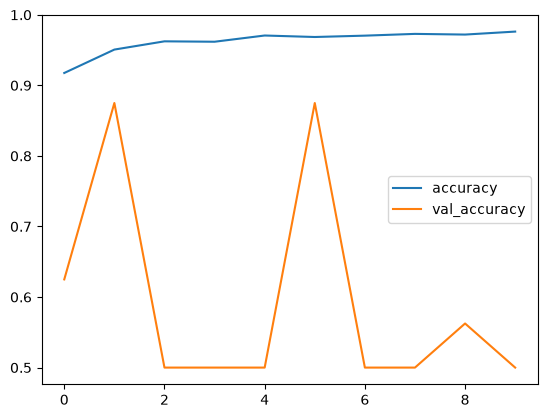

In [34]:
history_df = pd.DataFrame(history.history)
history_df.loc[:,['loss','val_loss']].plot()
history_df.loc[:,['accuracy','val_accuracy']].plot()

plt.show()

In [35]:
loss,accuracy = model.evaluate(Test)
print('The accuracy of the model on test dataset is', np.round(accuracy*100))

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 489ms/step - accuracy: 0.6266 - loss: 3.4267
The accuracy of the model on test dataset is 63.0
